# 02 — Baseline Models

**Group D — Grid Load Prediction**

Establish a performance floor. Screen a shortlist of models on a single train/test split (**Assignment Task 10**). The winners here go into the cross-validated pass in `experiments/model_02_cv_selection.ipynb`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
REPO = Path.cwd()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
import numpy as np
import pandas as pd
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Repo root:", REPO)
from sklearn.model_selection import train_test_split
from src.data_loading import PROCESSED_DIR, TARGET
from src.features import build_features, split_xy
from src.modeling import candidate_models
from src.evaluation import regression_metrics, scoreboard

Repo root: /home/winzer/code/python/class/aion-gridload


## Load cleaned data & build features

In [2]:
clean_path = PROCESSED_DIR / 'grid_load_clean.csv'
df = pd.read_csv(clean_path)
feat = build_features(df)
X, y = split_xy(feat)
print('Feature matrix:', X.shape)
X.head()

Feature matrix: (1489, 21)


,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,Hour_sin,Hour_cos,DoW_sin,DoW_cos,is_weekend,is_daytime,is_evening_peak,Temp_x_Humidity,Pop_x_Industrial,Region_Central,Region_Eastern,Region_Northern,Region_Western
0,20.0,0.0,26.7,52.0,3.1,93.0,89.0,0.03,-8.660254e-01,0.500000,0.000000,1.000000,0,0,1,1388.4,8277.0,1,0,0,0
1,13.0,0.0,18.5,63.0,3.7,95.0,89.0,0.38,-2.588190e-01,-0.965926,0.000000,1.000000,0,1,0,1165.5,8455.0,0,1,0,0
2,14.0,4.0,22.7,90.0,3.3,71.0,55.0,0.13,-5.000000e-01,-0.866025,-0.433884,-0.900969,0,1,0,2043.0,3905.0,0,0,0,1
3,10.0,0.0,19.6,41.0,0.1,75.0,78.0,0.45,5.000000e-01,-0.866025,0.000000,1.000000,0,1,0,803.6,5850.0,0,0,1,0
4,12.0,0.0,27.4,88.0,0.0,86.0,58.0,0.70,1.224647e-16,-1.000000,0.000000,1.000000,0,1,0,2411.2,4988.0,0,0,1,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)

train: (1191, 21) | test: (298, 21)


## Task 10 — Train & screen candidate models
Includes a mean-predictor baseline: any real model must beat it.

In [4]:
results = {}
for name, model in candidate_models().items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = regression_metrics(y_test, preds)
board = scoreboard(results)
board

,RMSE,MAE,R2,MAPE
Ridge,12.759,10.091,0.984,1.691
LinearRegression,12.761,10.074,0.984,1.688
GradientBoosting,12.857,10.228,0.984,1.706
RandomForest,18.944,14.810,0.965,2.482
DecisionTree,25.037,19.692,0.939,3.293
Baseline (mean),101.611,86.082,-0.000,14.622


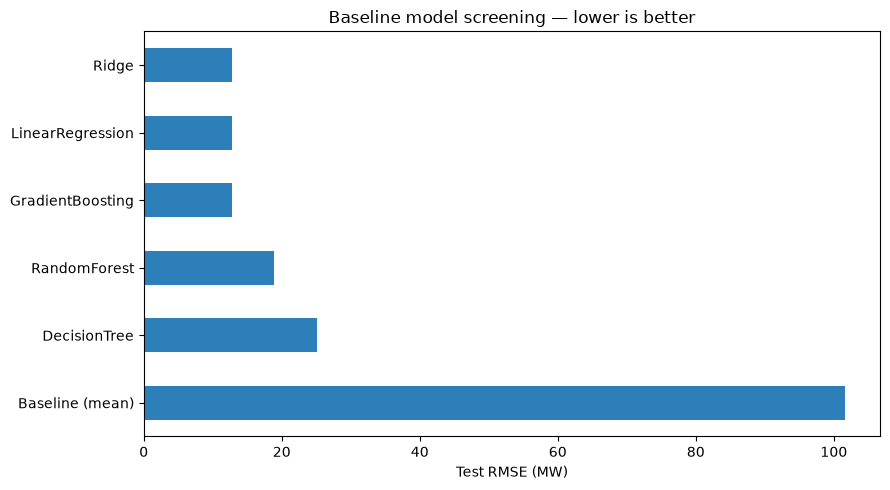

In [5]:
import matplotlib.pyplot as plt
from src.data_loading import FIGURES_DIR
fig, ax = plt.subplots(figsize=(9, 5))
board['RMSE'].plot.barh(ax=ax, color='#2c7fb8')
ax.invert_yaxis(); ax.set_xlabel('Test RMSE (MW)')
ax.set_title('Baseline model screening — lower is better')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'baseline_model_rmse.png', dpi=120)
plt.show()

## Result
The table + chart rank the candidates. Tree ensembles (RandomForest / GradientBoosting) are expected to lead on this tabular data. The top 2–3 carry forward to cross-validation and tuning.